# 01 — Data Collection

using `yfinance` to pull historical price data for 5 stocks — 2 US, 3 Indian.  
saving to `data/raw/` so we don't re-download every time we run the next notebooks.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

print('libraries loaded')

libraries loaded


## stocks and date range

In [2]:
# picked 2 US large-caps + 3 Indian large-caps across different sectors
TICKERS = {
    'AAPL'        : 'Apple (NASDAQ)',
    'MSFT'        : 'Microsoft (NASDAQ)',
    'RELIANCE.NS' : 'Reliance Industries (NSE)',
    'TCS.NS'      : 'Tata Consultancy Services (NSE)',
    'HDFCBANK.NS' : 'HDFC Bank (NSE)',
}

START = '2015-01-01'
END   = '2026-01-01'

RAW_DIR = '../data/raw'
os.makedirs(RAW_DIR, exist_ok=True)

print(f'{len(TICKERS)} stocks | {START} to {END}')

5 stocks | 2015-01-01 to 2026-01-01


## download and save

`auto_adjust=True` — adjusts prices for splits and dividends automatically.  
saves each ticker as a separate CSV with `_` instead of `.` in the filename.

In [3]:
raw_data = {}

for ticker, name in TICKERS.items():
    print(f'fetching {ticker} ...')

    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)

    # yfinance sometimes returns multi-level columns for single tickers
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.dropna(inplace=True)

    fname = ticker.replace('.', '_') + '.csv'
    df.to_csv(os.path.join(RAW_DIR, fname))

    raw_data[ticker] = df
    print(f'  {len(df)} trading days  ->  data/raw/{fname}\n')

print('all done.')

fetching AAPL ...
  2766 trading days  ->  data/raw/AAPL.csv

fetching MSFT ...
  2766 trading days  ->  data/raw/MSFT.csv

fetching RELIANCE.NS ...
  2716 trading days  ->  data/raw/RELIANCE_NS.csv

fetching TCS.NS ...
  2716 trading days  ->  data/raw/TCS_NS.csv

fetching HDFCBANK.NS ...
  2716 trading days  ->  data/raw/HDFCBANK_NS.csv

all done.


## quick sanity check

In [4]:
summary = []
for ticker, df in raw_data.items():
    summary.append({
        'ticker'       : ticker,
        'start'        : str(df.index.min().date()),
        'end'          : str(df.index.max().date()),
        'trading_days' : len(df),
        'missing_vals' : int(df.isnull().sum().sum()),
    })

pd.DataFrame(summary)

,ticker,start,end,trading_days,missing_vals
0,AAPL,2015-01-02,2025-12-31,2766,0
1,MSFT,2015-01-02,2025-12-31,2766,0
2,RELIANCE.NS,2015-01-01,2025-12-31,2716,0
3,TCS.NS,2015-01-01,2025-12-31,2716,0
4,HDFCBANK.NS,2015-01-01,2025-12-31,2716,0


## what the raw data looks like

In [5]:
print('AAPL — last 5 rows:')
raw_data['AAPL'].tail()

AAPL — last 5 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.892975,274.859323,272.353968,273.651575,21521800
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200
2025-12-30,272.573578,273.571723,271.775074,272.304090,22139600
2025-12-31,271.355835,273.172467,271.246054,272.553622,27293600


## normalised price history

dividing by the first price so all 5 stocks start at 1.0 — makes them comparable on one chart even though Indian stocks are in INR and US stocks are in USD.

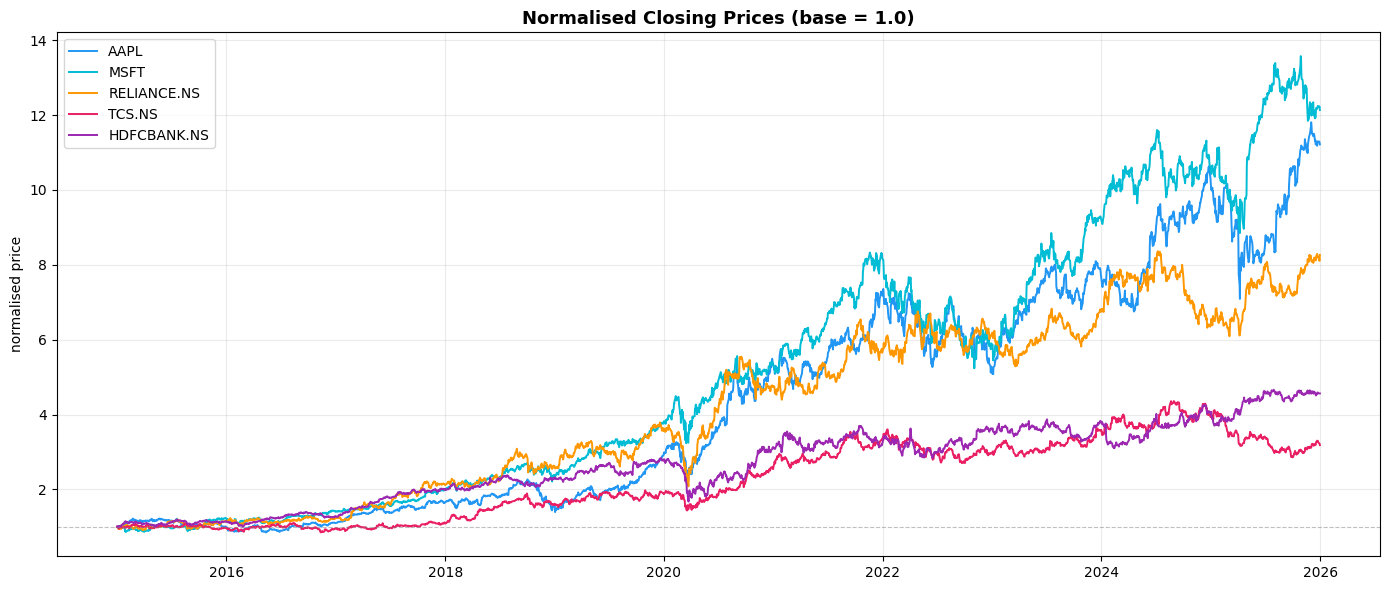

saved -> plots/01_price_history.png


In [6]:
colors = ['#2196F3', '#00BCD4', '#FF9800', '#E91E63', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (ticker, df) in enumerate(raw_data.items()):
    normed = df['Close'] / df['Close'].iloc[0]
    ax.plot(df.index, normed, label=ticker, color=colors[i], linewidth=1.4)

ax.axhline(1, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Normalised Closing Prices (base = 1.0)', fontsize=13, fontweight='bold')
ax.set_ylabel('normalised price')
ax.legend()
ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../plots/01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/01_price_history.png')

## daily return distribution

checking how returns are spread — mostly normal-ish with fat tails (big moves happen more than normal distribution would predict).

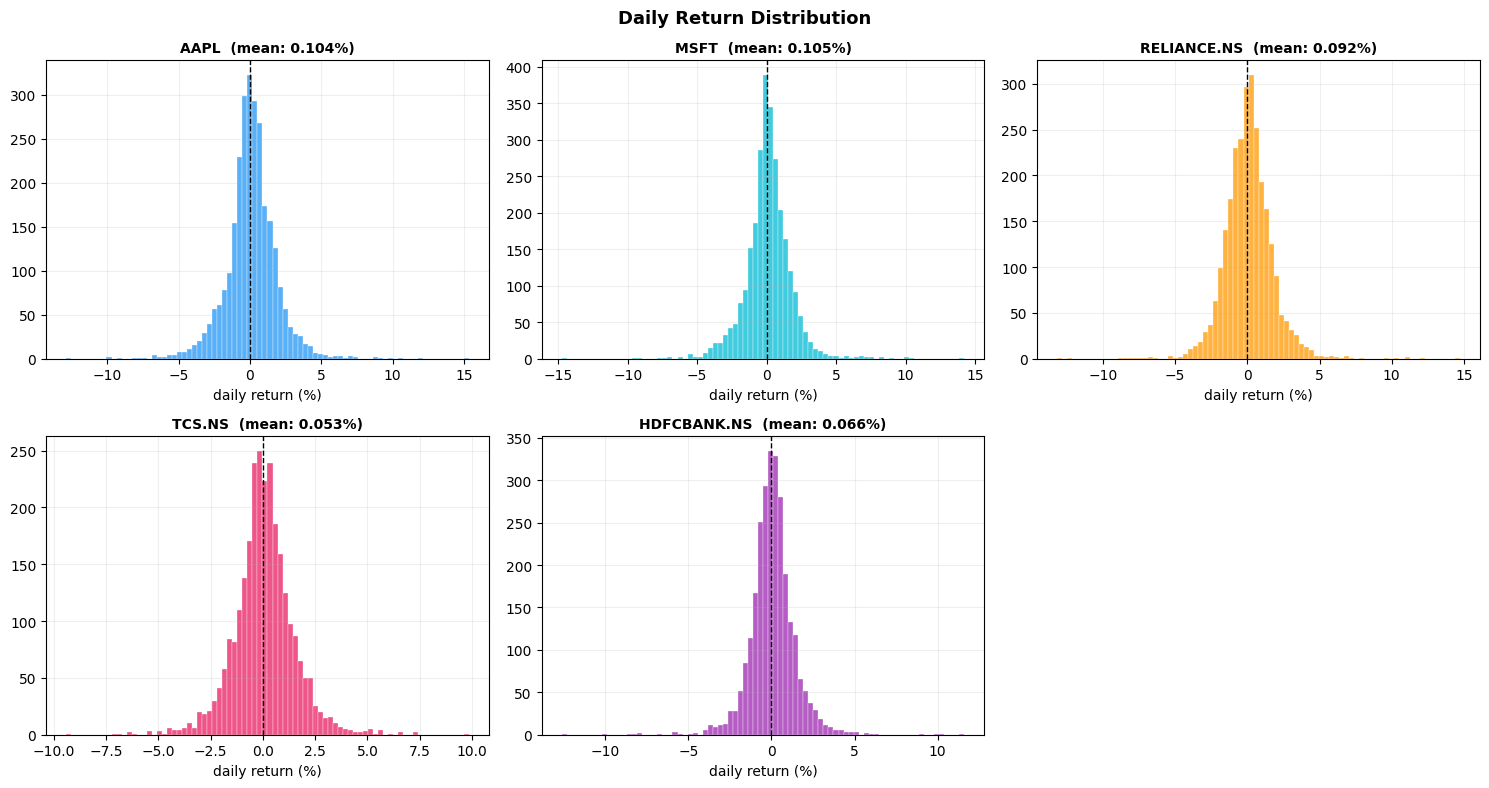

saved -> plots/01_return_dist.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (ticker, df) in enumerate(raw_data.items()):
    daily_ret = df['Close'].pct_change().dropna() * 100
    ax = axes[i]
    ax.hist(daily_ret, bins=80, color=colors[i], alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f"{ticker}  (mean: {daily_ret.mean():.3f}%)", fontsize=10, fontweight='bold')
    ax.set_xlabel('daily return (%)')
    ax.grid(alpha=0.2)

axes[-1].set_visible(False)
fig.suptitle('Daily Return Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/01_return_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/01_return_dist.png')

## up vs down day split

this is important — it tells us what the "always predict up" baseline accuracy will be.  
markets go up more than down historically, so the baseline isn't exactly 50%.

In [8]:
print(f"{'ticker':15s}  {'up days':>10}  {'down days':>10}  {'up %':>8}")
print('-' * 50)

for ticker, df in raw_data.items():
    ret       = df['Close'].pct_change().dropna()
    up        = (ret > 0).sum()
    down      = (ret <= 0).sum()
    total     = up + down
    print(f"{ticker:15s}  {up:>10}  {down:>10}  {up/total*100:>7.1f}%")

ticker              up days   down days      up %
--------------------------------------------------
AAPL                   1470        1295     53.2%
MSFT                   1480        1285     53.5%
RELIANCE.NS            1412        1303     52.0%
TCS.NS                 1375        1340     50.6%
HDFCBANK.NS            1416        1299     52.2%


---

data is saved. next up: `02_feature_engineering.ipynb` — building the features and labeling each day as up or down.